# Machine Learning com jogos da Steam

Vamos responder a duas perguntas:

1. **Random Forest Regressor:** podemos prever o **preço** de um jogo?
2. **Random Forest Classifier:** podemos classificar o **alcance** de um jogo?

Fluxo básico:

**Dados → características → treinamento → previsão → avaliação**


## 1. Bibliotecas

- `pandas` para os dados;
- `matplotlib` para visualização;
- `scikit-learn` para Machine Learning.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score


## 2. Carregando os dados

In [ ]:
# Importação dos dados CSV
# Dataset local
# URL = "train-00000-of-00001.parquet"
URL = "https://huggingface.co/datasets/FronkonGames/steam-games-dataset/resolve/main/data/train-00000-of-00001.parquet"

dados = pd.read_parquet(URL)

print("Quantidade de jogos:", len(dados))
dados.head()


Quantidade de jogos: 124146


,appID,name,release_date,estimated_owners,peak_ccu,required_age,price,dlc_count,detailed_description,short_description,...,median_playtime_forever,median_playtime_2weeks,developers,publishers,categories,genres,tags,screenshots,movies,packages
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,,,...,0,0,[],[],[],[],[],[https://shared.akamai.steamstatic.com/store_i...,[],[]
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,0,"Springtime, April: when the cherry trees come ...","Spring has come, and our protagonist, Yukinari...",...,8,0,[minori],[MangaGamer],"[Single-player, Steam Trading Cards, Steam Clo...",[Adventure],[],[https://shared.akamai.steamstatic.com/store_i...,[],"[{""title"": ""Buy Supipara - Chapter 1 Spring Ha..."
2,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,"Immerse yourself in the most beloved, mystical...",Discover an entrancing and spectacular world!,...,0,0,[Somer Games],[8floor],"[Single-player, Family Sharing]",[Casual],[],[https://shared.akamai.steamstatic.com/store_i...,[],"[{""title"": ""Buy Mystery Solitaire The Black Ra..."
3,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",Yuha! I'll start the broadcast! Hakko's extrem...,...,0,0,[유진게임즈],[유진게임즈],"[Single-player, Steam Achievements, Family Sha...","[Casual, Indie, Simulation]",[],[https://shared.akamai.steamstatic.com/store_i...,[],"[{""title"": ""Buy \ubc84\ud29c\ubc84 \ud30c\ub77..."
4,3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,Its not just a Maze; its a Quest! Enter the ca...,Its not just a Maze; its a Quest! Enter the ca...,...,0,0,[Reality Expanded LLC],[Reality Expanded LLC],"[Single-player, VR Only, Steam Leaderboards, F...","[Action, Early Access]",[],[https://shared.akamai.steamstatic.com/store_i...,[],"[{""title"": ""Buy Maze Quest VR"", ""description"":..."


# 3. Preparando as características

Algumas informações do dataset são **multilabel**.

Um jogo pode ter vários gêneros:

`[Casual, Indie, Simulation]`

Várias categorias:

`[Single-player, Steam Achievements, Family Sharing]`

E vários idiomas:

`[English, French, German, Russian]`

Para o modelo, transformaremos essas informações em variáveis 0/1.

Exemplo:

| Jogo | Action | Indie | Simulation |
|---|---:|---:|---:|
| Jogo A | 1 | 1 | 0 |
| Jogo B | 0 | 1 | 1 |

Isso é uma forma simples de **multi-hot encoding**.


### Vamos começar com as características mais importantes

Usaremos:

- ano de lançamento;
- quantidade de DLCs;
- avaliações positivas;
- avaliações negativas;
- recomendações;
- plataformas: Windows, Mac e Linux;
- gêneros;
- idiomas.

Categorias e idiomas ficam fora do modelo inicial para não criar centenas de variáveis em uma amostra pequena.


In [3]:
# -------------------------------------------------------
# JOGOS LANÇADOS POR ANO
# -------------------------------------------------------
dados["release_date_dt"] = pd.to_datetime(
    dados["release_date"],
    errors="coerce"
)

# Extrair a quantidade de jogos lançados por ano
dados["release_year"] = dados["release_date_dt"].dt.year

In [4]:
# -------------------------------------------------------
# 22 IDIOMAS MAIS PRESENTES NOS JOGOS 
# -------------------------------------------------------
import re

idiomas = ["English", "Chinese", "German", "French", "Japanese", "Spanish", "Russian", "Italian",
           "Korean", "Portuguese", "Polish", "Turkish", "Dutch", "Ukrainian", "Czech",
           "Swedish", "Thai", "Hungarian", "Arabic", "Danish", "Norwegian", "Finnish"]

def possui_idioma(valor, idioma):

    if valor is None:
        return 0

    texto = str(valor)

    if re.search(idioma, texto, re.IGNORECASE):
        return 1

    return 0

for idioma in idiomas:

    dados[idioma] = dados["supported_languages"].apply(
        lambda x: possui_idioma(x, idioma)
    )

colunas_idiomas = [
    idioma for idioma in idiomas
]

idiomas_ml = dados[colunas_idiomas]

In [5]:
# -------------------------------------------------------
# GÊNEROS
# -------------------------------------------------------

generos = dados["genres"].explode()

generos = pd.crosstab(
    generos.index,
    generos
)

generos = generos.reindex(
    dados.index,
    fill_value=0
)

generos

genres,360 Video,Accounting,Action,Adventure,Animation & Modeling,Audio Production,Casual,Design & Illustration,Documentary,Early Access,...,Short,Simulation,Software Training,Sports,Strategy,Tutorial,Utilities,Video Production,Violent,Web Publishing
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,0,0,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124141,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
124142,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
124143,0,0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
124144,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [6]:
# -------------------------------------------------------
# CATEGORIAS
# -------------------------------------------------------

categorias = dados["categories"].explode()

categorias = pd.crosstab(
    categorias.index,
    categorias
)

categorias = categorias.reindex(
    dados.index,
    fill_value=0
)

categorias

categories,Adjustable Difficulty,Adjustable Text Size,Camera Comfort,Captions available,Chat Speech-to-text,Chat Text-to-speech,Co-op,Color Alternatives,Commentary available,Cross-Platform Multiplayer,...,SteamVR Collectibles,Stereo Sound,Subtitle Options,Surround Sound,Touch Only Option,Tracked Controller Support,VR Only,VR Support,VR Supported,Valve Anti-Cheat enabled
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124141,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
124142,1,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
124143,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
124144,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
# -------------------------------------------------------
# PLATAFORMAS
# -------------------------------------------------------

plataformas = pd.DataFrame(index=dados.index)

plataformas["Windows"] = dados["windows"].fillna(False).astype(int)
plataformas["Mac"] = dados["mac"].fillna(False).astype(int)
plataformas["Linux"] = dados["linux"].fillna(False).astype(int)

plataformas

,Windows,Mac,Linux
0,1,0,0
1,1,0,0
2,1,1,0
3,1,0,0
4,1,0,0
...,...,...,...
124141,1,0,0
124142,1,0,0
124143,1,0,0
124144,1,0,0


In [8]:
# Colunas numéricas
numericas = [
    "release_year",
    "dlc_count",
    "positive",
    "negative",
    "recommendations"
]

for coluna in numericas:
    dados[coluna] = pd.to_numeric(dados[coluna], errors="coerce").fillna(0)

# Características finais
X = pd.concat([
    dados[numericas],
    plataformas,
    idiomas_ml,
    generos,
    categorias    
], axis=1)

print("Quantidade de características:", X.shape[1])
X.head()


Quantidade de características: 121


,release_year,dlc_count,positive,negative,recommendations,Windows,Mac,Linux,English,Chinese,...,SteamVR Collectibles,Stereo Sound,Subtitle Options,Surround Sound,Touch Only Option,Tracked Controller Support,VR Only,VR Support,VR Supported,Valve Anti-Cheat enabled
0,2023,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2016,0,252,3,231,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,2019,0,21,3,0,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,2024,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2025,0,0,0,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,0


# Parte 1 — Random Forest Regressor

**RandomForestRegressor** é um modelo que combina várias **árvores de decisão** para prever um **valor numérico**.

No nosso caso:

> **Usa as características de um jogo para prever seu preço.**

As árvores fazem previsões diferentes e o modelo combina essas previsões para chegar ao resultado final.

In [9]:
# Variável que queremos prever
y = pd.to_numeric(
    dados["price"],
    errors="coerce"
).fillna(0)

# Separação: 80% treino / 20% teste
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Criar o modelo
modelo_reg = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Treinar
modelo_reg.fit(X_treino, y_treino)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

## Métricas

**MAE — Erro Absoluto Médio**

Indica, em média, quanto a previsão ficou distante do preço real.

**R² — coeficiente de determinação**

Indica quanto da variação dos preços é explicada pelo modelo.

**RMSE — Raiz do Erro Quadrático Médio**

Indica o tamanho médio dos erros de previsão, dando maior peso aos erros grandes.

> O modelo aprende com os dados de treinamento e depois tenta prever dados que não viu.

In [10]:
previsoes = modelo_reg.predict(X_teste)

mae = mean_absolute_error(y_teste, previsoes)
rmse = mean_squared_error(y_teste, previsoes) ** 0.5
r2 = r2_score(y_teste, previsoes)

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²:", round(r2, 2))

MAE: 3.15
RMSE: 7.57
R²: 0.53


## Características mais influenciam a previsão

In [11]:
# Quais características mais influenciam a previsão? 
importancias = pd.Series(
    modelo_reg.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importancias.head(15))

Steam Leaderboards    0.106560
positive              0.091477
release_year          0.082691
negative              0.070570
Linux                 0.055394
Steam Cloud           0.046589
Finnish               0.039728
Chinese               0.033854
Simulation            0.029522
Action                0.026945
Family Sharing        0.026865
Mac                   0.023284
Thai                  0.020258
Strategy              0.016228
RPG                   0.016228
dtype: float64


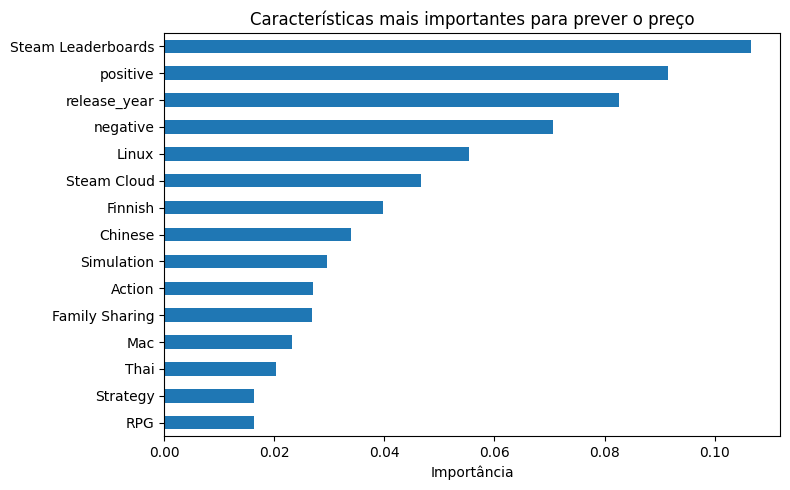

In [12]:
# Quais características de um jogo mais contribuem para explicar seu preço?
importancias.head(15).sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Características mais importantes para prever o preço")
plt.xlabel("Importância")
plt.tight_layout()
plt.show()

In [13]:
# Salvar o modelo RandomForestRegressor 
# Modelo Prever o Preço
import joblib

joblib.dump(modelo_reg, "modelo_preco.pkl")

print("Modelo salvo!")

Modelo salvo!


In [14]:
# Importação do modelo saldo 
# (Não precisa carregar e executar o treinamento e teste novamente)
import joblib

modelo_preco = joblib.load("modelo_preco.pkl")

In [15]:
# -------------------------------------------------------
# NOVO JOGO
# -------------------------------------------------------
novo_jogo = pd.DataFrame(
    0,
    index=[0],
    columns=modelo_preco.feature_names_in_
)

# Características numéricas
novo_jogo["release_year"] = 2025
novo_jogo["dlc_count"] = 0
novo_jogo["positive"] = 500
novo_jogo["negative"] = 50
novo_jogo["recommendations"] = 1000


# -------------------------------------------------------
# PLATAFORMAS
# -------------------------------------------------------

novo_jogo["Windows"] = 1
novo_jogo["Mac"] = 1
novo_jogo["Linux"] = 1


# -------------------------------------------------------
# IDIOMAS
# -------------------------------------------------------

novo_jogo["English"] = 1
novo_jogo["Portuguese"] = 1
novo_jogo["Spanish"] = 1


# -------------------------------------------------------
# GÊNEROS
# -------------------------------------------------------

novo_jogo["Action"] = 1
novo_jogo["Indie"] = 1
novo_jogo["Adventure"] = 1
novo_jogo["Early Access"] = 1


# -------------------------------------------------------
# CATEGORIAS
# -------------------------------------------------------

novo_jogo["Single-player"] = 1
novo_jogo["Steam Achievements"] = 1
novo_jogo["Steam Cloud"] = 1
novo_jogo["Co-op"] = 1


In [16]:
# -------------------------------------------------------
# PREVISÃO
# -------------------------------------------------------

preco = modelo_preco.predict(novo_jogo)[0]

print(f"Preço previsto: $ {preco:.2f}")

Preço previsto: $ 9.85


# Parte 2 — Random Forest Classifier

Agora mudamos a pergunta:

> **Podemos classificar o alcance de um jogo?**

O dataset já possui `estimated_owners`, com faixas como:

- `0 - 20000`
- `20000 - 50000`
- `50000 - 100000`
- `100000 - 200000`
- ...
- `50000000 - 100000000`

Para deixar a demonstração simples, vamos agrupá-las em apenas três classes:

- **Baixo:** até 20 mil owners;
- **Médio:** de 20 mil a 500 mil;
- **Alto:** acima de 500 mil.

Assim o modelo responde:

> **Qual é a faixa de alcance provável deste jogo?**


In [17]:
def faixa_owners(faixa):
    if pd.isna(faixa):
        return None

    inicio = int(str(faixa).split(" - ")[0])

    if inicio <= 0:
        return "Baixo"
    elif inicio <= 20000:
        return "Baixo"
    elif inicio <= 500000:
        return "Médio"
    else:
        return "Alto"

dados["faixa_alcance"] = dados["estimated_owners"].apply(faixa_owners)

print(dados["faixa_alcance"].value_counts())


faixa_alcance
Baixo    109975
Médio     12817
Alto       1354
Name: count, dtype: int64


### Treinando o Random Forest

Agora a saída não é um número.

Ela é uma **categoria**:

`Baixo`, `Médio` ou `Alto`.

Por isso usamos um **Classifier**.


In [18]:
y = dados["faixa_alcance"]

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

modelo_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

modelo_clf.fit(X_treino, y_treino)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Métricas

**Accuracy Score**

Indica a proporção de previsões classificadas corretamente pelo modelo.

In [19]:
previsoes = modelo_clf.predict(X_teste)

print("Acurácia:", round(accuracy_score(y_teste, previsoes), 2))

Acurácia: 0.95


In [20]:
# Salvar o modelo RandomForestClassifier (Modelo Alcance)
import joblib

joblib.dump(modelo_clf, "modelo_alcance.pkl")
print("Modelo salvo!")

Modelo salvo!


In [21]:
# Importação do modelo saldo 
# (Não precisa carregar e executar o treinamento e teste novamente)
import joblib

modelo_alcance = joblib.load("modelo_alcance.pkl")

## Classificando um novo jogo

Usamos as mesmas características do exemplo anterior.

Agora o modelo responde com uma **faixa de alcance**.


In [22]:
classe = modelo_alcance.predict(novo_jogo)[0]

print("Alcance previsto:", classe)


Alcance previsto: Baixo


# Regressão × Classificação

| Problema | O modelo responde | Algoritmo |
|---|---|---|
| Prever preço | **Quanto?** | RandomForestRegressor |
| Prever alcance | **Qual faixa?** | Random Forest Classifier |

**Regressão → prevê um valor numérico**

**Classificação → prevê uma categoria**

E nos dois casos seguimos o mesmo processo:

**Dados → X e y → treino → teste → previsão → avaliação**

### Observação importante

`estimated_owners` representa uma **estimativa de proprietários**, não necessariamente o número exato de downloads.
